In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Suppress common warnings to keep output clean (fit warnings, convergence, etc.)
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# Load the dataset
df = pd.read_csv("../data/delhi_aqi.csv")
df = df.drop(columns=['City'])

# Convert 'Date' column to datetime and set it as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.index.freq = 'D' 

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
Date,,,,,,,,,,,,,
2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,472,Severe
2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,454,Severe
2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,143,Moderate
2015-01-04,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,319,Very Poor
2015-01-05,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,325,Very Poor


In [22]:
# Display basic information about the dataset
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.DataFrame'>
DatetimeIndex: 2009 entries, 2015-01-01 to 2020-07-01
Freq: D
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PM2.5       2009 non-null   float64
 1   PM10        2009 non-null   float64
 2   NO          2009 non-null   float64
 3   NO2         2009 non-null   float64
 4   NOx         2009 non-null   float64
 5   NH3         2009 non-null   float64
 6   CO          2009 non-null   float64
 7   SO2         2009 non-null   float64
 8   O3          2009 non-null   float64
 9   Benzene     2009 non-null   float64
 10  Toluene     2009 non-null   float64
 11  AQI         2009 non-null   int64  
 12  AQI_Bucket  2009 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 219.7 KB



TRAIN / TEST SPLIT
Train shape : (1826, 13)
Test shape  : (183, 13)

Periods
Train : 2015-01-01 00:00:00 -> 2019-12-31 00:00:00
Test  : 2020-01-01 00:00:00 -> 2020-07-01 00:00:00


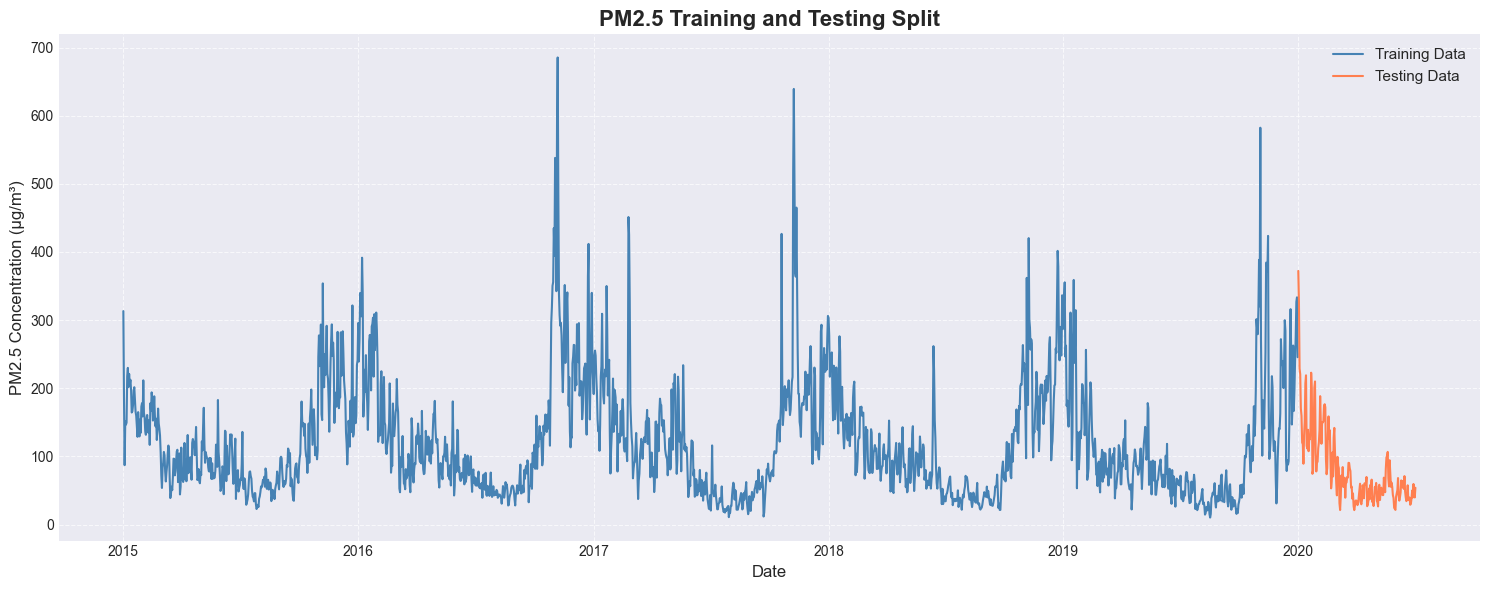

In [3]:
# ============================================
# IMPORTANT: Train-Test Split BEFORE any analysis
# This prevents data leakage in time series
# ============================================

print("\n" + "="*70)
print("TRAIN / TEST SPLIT")
print("="*70)

train = df[:'2019-12-31'].copy()
test  = df['2020-01-01':].copy()

print(f"Train shape : {train.shape}")
print(f"Test shape  : {test.shape}")

print("\nPeriods")
print(f"Train : {train.index.min()} -> {train.index.max()}")
print(f"Test  : {test.index.min()} -> {test.index.max()}")

y_train = train["PM2.5"]
y_test = test["PM2.5"]

# Plot the split
plt.figure(figsize=(15, 6))
plt.plot(y_train, label='Training Data', color='steelblue')
plt.plot(y_test, label='Testing Data', color='coral')
plt.title('PM2.5 Training and Testing Split', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('PM2.5 Concentration (μg/m³)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


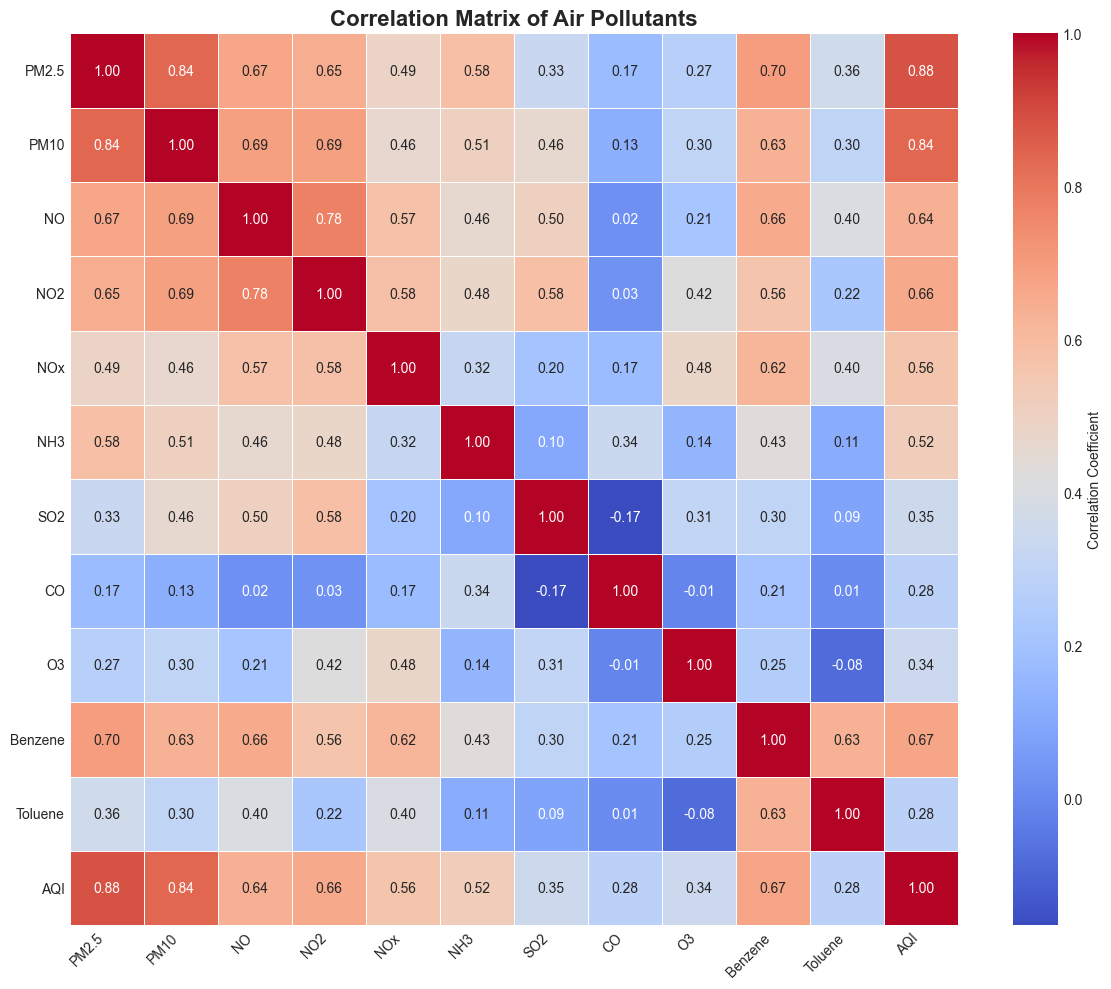


Correlations with PM2.5 (sorted):
PM2.5      1.000000
AQI        0.882312
PM10       0.838732
Benzene    0.698466
NO         0.668167
NO2        0.646748
NH3        0.584104
NOx        0.487765
Toluene    0.359590
SO2        0.331168
O3         0.266755
CO         0.171724
Name: PM2.5, dtype: float64

Multicollinearity Analysis (VIF)
Feature       VIF
    AQI 23.604553
    NO2 23.339280
   PM10 20.738391
Benzene 10.515706
    NOx  8.723562
    NH3  8.244765
    SO2  8.098366
     O3  7.934288
     NO  7.589427
Toluene  3.996051

✓ Good features (VIF < 10): ['NOx', 'NH3', 'SO2', 'O3', 'NO', 'Toluene']


In [24]:
# Correlation matrix
corr = df[['PM2.5','PM10','NO','NO2','NOx','NH3','SO2','CO','O3','Benzene','Toluene','AQI']].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Air Pollutants', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Identify top correlations with PM2.5
pm25_corr = corr['PM2.5'].sort_values(ascending=False)
print("\nCorrelations with PM2.5 (sorted):")
print(pm25_corr)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select features with reasonable correlation (EXCLUDING PM2.5)
potential_features = pm25_corr[(pm25_corr > 0.2) & (pm25_corr.index != 'PM2.5')].index.tolist()
X_vif = df[potential_features].copy()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)
print("\nMulticollinearity Analysis (VIF)")
print(vif_data.to_string(index=False))

# Recommend features with good VIF
good_vif_features = vif_data[vif_data['VIF'] < 10]['Feature'].tolist()
print(f"\n✓ Good features (VIF < 10): {good_vif_features}")

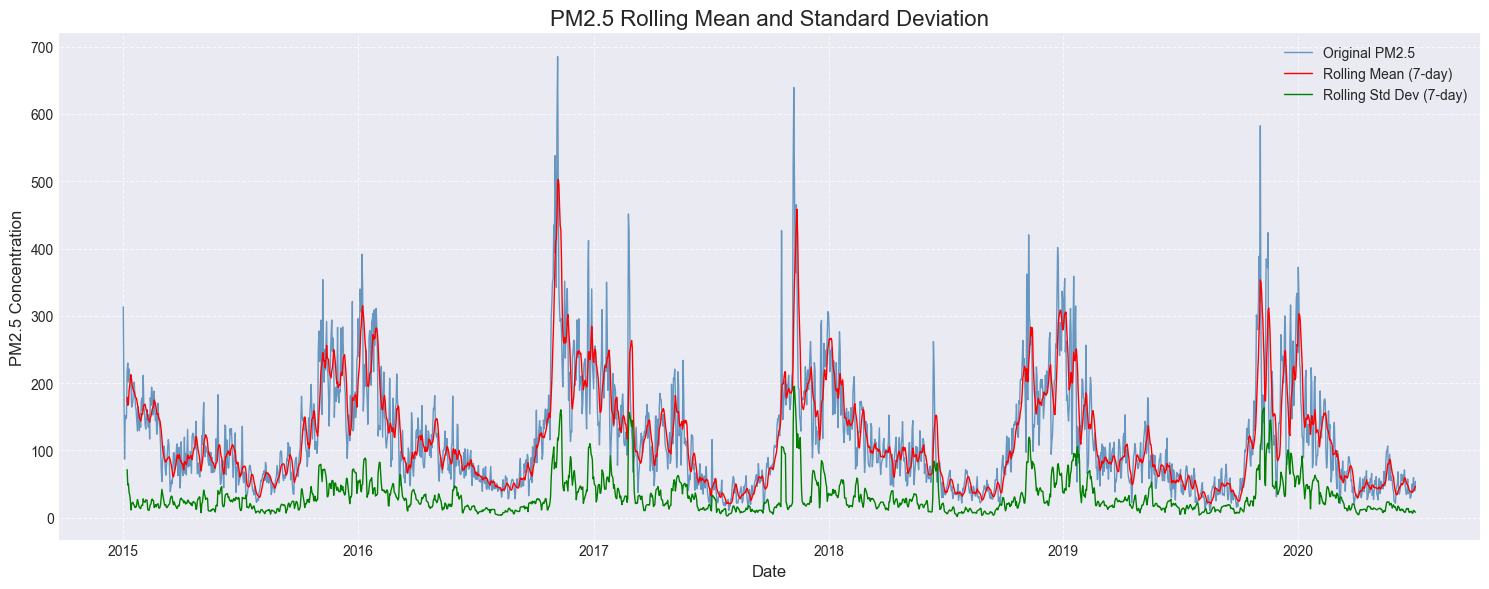

In [25]:
# ============================================
# Rolling Statistics
# ============================================
rolling_mean = df['PM2.5'].rolling(window=7).mean()
rolling_std = df['PM2.5'].rolling(window=7).std()

plt.figure(figsize=(15, 6))
plt.plot(df['PM2.5'], label='Original PM2.5', alpha=0.8, color='steelblue', linewidth=1)
plt.plot(rolling_mean, label='Rolling Mean (7-day)', color='red', linewidth=1)
plt.plot(rolling_std, label='Rolling Std Dev (7-day)', color='green', linewidth=1)
plt.title('PM2.5 Rolling Mean and Standard Deviation', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('PM2.5 Concentration', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### Rolling Mean and Rolling Standard Deviation Analysis

* **Strong Seasonal Pattern**
    * The PM2.5 series exhibits a clear seasonal pattern, with recurring peaks during winter months and lower concentrations during summer periods.
    * Similar peak-and-trough cycles are observed across multiple years, indicating the presence of annual seasonality.
    * This suggests that seasonal components should be incorporated into the forecasting model.

* **Non-Constant Variance (Heteroscedasticity)**
    * The rolling standard deviation changes considerably over time rather than remaining stable.
    * Higher variability is observed during high-pollution periods, while lower variability occurs during cleaner periods.
    * This indicates heteroscedasticity in the original series.
    * A logarithmic or Box-Cox transformation may be considered to stabilize the variance before model fitting.

* **Non-Stationary Mean**
    * The rolling mean fluctuates substantially throughout the observation period.
    * Since the mean is not constant over time, the original PM2.5 series is likely non-stationary.
    * Further statistical tests such as the Augmented Dickey-Fuller (ADF) test are required to confirm stationarity and determine the appropriate differencing order.

* **Presence of Extreme Values and Short-Term Volatility**
    * The series contains numerous sharp spikes and abrupt fluctuations.
    * These extreme observations may be associated with short-term environmental or meteorological events.
    * Such volatility increases the complexity of the forecasting task and should be captured by the time-series model.

* **No Strong Long-Term Trend**
    * No clear long-term upward or downward trend is observed over the study period.
    * Seasonal fluctuations appear to be the dominant feature of the series.
    * This characteristic is favorable for short-term forecasting once seasonality and non-stationarity are properly addressed.

#### Conclusion

* The PM2.5 series demonstrates strong seasonality, non-constant variance, and a non-stationary mean.
* Therefore, data transformation and differencing may be required before model estimation.
* These characteristics suggest that seasonal forecasting models such as SARIMA are appropriate candidates for modeling PM2.5 concentrations.

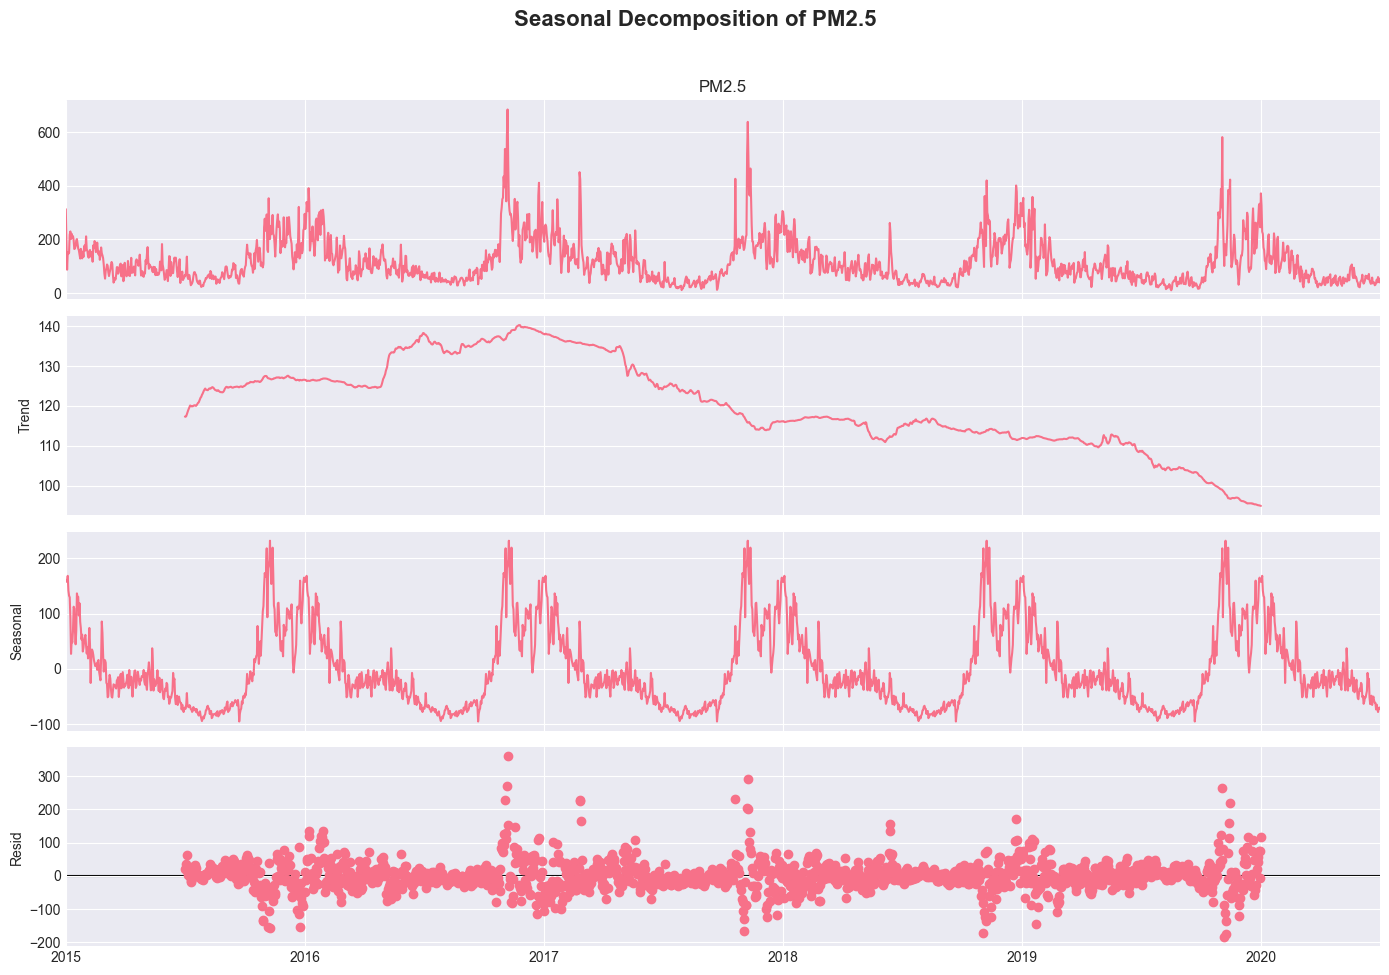

In [26]:
# ============================================
# SEASONAL DECOMPOSITION
# ============================================

# Seasonal decomposition using additive model
# Period = 7 for weekly seasonality in daily data
plt.rcParams['figure.figsize'] = (14, 10)

decomposition = seasonal_decompose(
    df['PM2.5'],
    model='additive',
    period=365  # Weekly seasonality for daily data
)

fig = decomposition.plot()
fig.suptitle('Seasonal Decomposition of PM2.5', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


#### Seasonal Decomposition (Annual Seasonality, s = 365)

- **Strong annual seasonality detected**
  - The seasonal component exhibits a clear and repeating yearly pattern.
  - PM2.5 levels tend to increase during winter months and decrease during summer months.

- **Long-term trend exists**
  - The trend component changes gradually over time rather than remaining constant.
  - A slight downward trend is observed after 2017, suggesting some long-run improvement in air quality.

- **Seasonality is much stronger than weekly effects**
  - Seasonal fluctuations range roughly from -100 to +220 μg/m³.
  - The magnitude is substantially larger than the weekly seasonal pattern observed with s = 7.

- **Residuals are centered around zero**
  - Most residuals fluctuate randomly around zero, indicating that the trend and annual seasonal components explain a large portion of the variation.

- **Presence of extreme pollution episodes**
  - Several large positive residual spikes remain unexplained by the decomposition.
  - These may correspond to exceptional events such as crop burning, weather inversions, fireworks, or other short-term pollution shocks.

#### Conclusion

- Annual seasonality (s = 365) is clearly present and dominates the PM2.5 dynamics.
- The yearly cycle appears more important than weekly seasonality.
- Results support considering annual seasonal effects in forecasting models.
- However, using SARIMA with s = 365 is computationally expensive for daily data spanning multiple years.

STATIONARITY TEST - ORIGINAL SERIES
ADF Statistic: -3.979863
P-value: 0.001520
Critical Values:
  1%: -3.434
  5%: -2.863
  10%: -2.568
✓ Series is STATIONARY (reject H0, p ≤ 0.05)

STATIONARITY TEST - FIRST DIFFERENCED SERIES (d=1)
ADF Statistic: -15.742717
P-value: 0.000000
Critical Values:
  1%: -3.434
  5%: -2.863
  10%: -2.568
✓ First differenced series is STATIONARY

STATIONARITY TEST - SEASONAL DIFFERENCED (s=7, D=1)
ADF Statistic: -9.572634
P-value: 0.000000
✓ Seasonal differenced series is STATIONARY


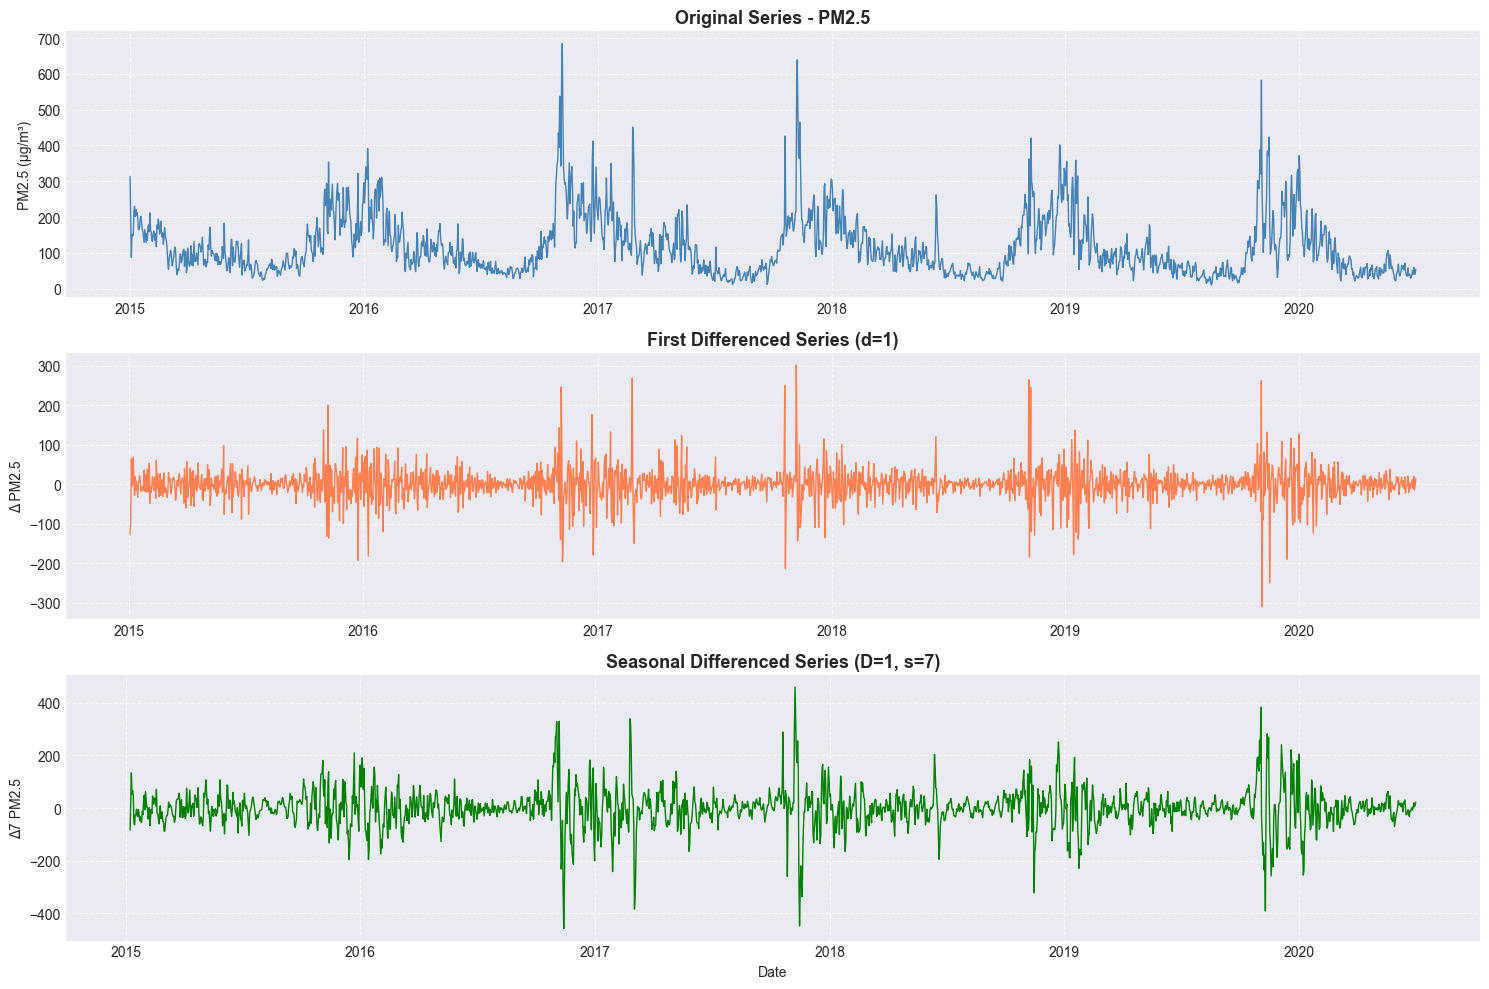


✓ RECOMMENDED: d=0, D=1


In [27]:
# ============================================
# STATIONARITY TESTING (Box-Jenkins Step 1)
# ============================================

print("="*60)
print("STATIONARITY TEST - ORIGINAL SERIES")
print("="*60)

result_original = adfuller(df['PM2.5'].dropna())
print(f'ADF Statistic: {result_original[0]:.6f}')
print(f'P-value: {result_original[1]:.6f}')
print(f'Critical Values:')
for key, value in result_original[4].items():
    print(f'  {key}: {value:.3f}')

if result_original[1] <= 0.05:
    print('✓ Series is STATIONARY (reject H0, p ≤ 0.05)')
    d_value = 0
else:
    print('✗ Series is NON-STATIONARY (fail to reject H0, p > 0.05)')
    d_value = 1

# Test first differencing
print("\n" + "="*60)
print("STATIONARITY TEST - FIRST DIFFERENCED SERIES (d=1)")
print("="*60)

diff_series = df['PM2.5'].diff().dropna()
result_diff = adfuller(diff_series)
print(f'ADF Statistic: {result_diff[0]:.6f}')
print(f'P-value: {result_diff[1]:.6f}')
print(f'Critical Values:')
for key, value in result_diff[4].items():
    print(f'  {key}: {value:.3f}')

if result_diff[1] <= 0.05:
    print('✓ First differenced series is STATIONARY')
else:
    print('✗ First differenced series is NON-STATIONARY')

# Test seasonal differencing (s=7 for weekly seasonality)
print("\n" + "="*60)
print("STATIONARITY TEST - SEASONAL DIFFERENCED (s=7, D=1)")
print("="*60)

seasonal_diff = df['PM2.5'].diff(periods=7).dropna()
result_seasonal_diff = adfuller(seasonal_diff)
print(f'ADF Statistic: {result_seasonal_diff[0]:.6f}')
print(f'P-value: {result_seasonal_diff[1]:.6f}')

if result_seasonal_diff[1] <= 0.05:
    print('✓ Seasonal differenced series is STATIONARY')
    D_value = 1
else:
    print('✗ Seasonal differenced series is NON-STATIONARY')
    D_value = 0

# Visualize differencing
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

axes[0].plot(df['PM2.5'], color='steelblue', linewidth=1)
axes[0].set_title('Original Series - PM2.5', fontsize=13, fontweight='bold')
axes[0].set_ylabel('PM2.5 (μg/m³)')
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].plot(diff_series, color='coral', linewidth=1)
axes[1].set_title('First Differenced Series (d=1)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Δ PM2.5')
axes[1].grid(True, linestyle='--', alpha=0.7)

axes[2].plot(seasonal_diff, color='green', linewidth=1)
axes[2].set_title(f'Seasonal Differenced Series (D=1, s=7)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Δ7 PM2.5')
axes[2].set_xlabel('Date')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"\n✓ RECOMMENDED: d={d_value}, D={D_value}")


In [28]:
# ============================================
# KPSS TEST - CONFIRM STATIONARITY
# ============================================
# KPSS H0: Series IS stationary
# ADF H0: Series HAS unit root (non-stationary)
# Use BOTH tests to confirm results

from statsmodels.tsa.stattools import kpss

print("\n" + "="*60)
print("KPSS TEST - ORIGINAL SERIES")
print("="*60)
print("H0: Series is stationary")

result_kpss_original = kpss(df['PM2.5'].dropna(), regression='c', nlags='auto')
print(f'KPSS Statistic: {result_kpss_original[0]:.6f}')
print(f'P-value: {result_kpss_original[1]:.6f}')
print(f'Critical Values:')
for key, value in result_kpss_original[3].items():
    print(f'  {key}: {value:.3f}')

if result_kpss_original[1] >= 0.05:
    print('✓ Series is STATIONARY (fail to reject H0, p ≥ 0.05)')
else:
    print('✗ Series is NON-STATIONARY (reject H0, p < 0.05)')

print("\n" + "="*60)
print("KPSS TEST - DIFFERENCED SERIES (d=1)")
print("="*60)

result_kpss_diff = kpss(diff_series, regression='c', nlags='auto')
print(f'KPSS Statistic: {result_kpss_diff[0]:.6f}')
print(f'P-value: {result_kpss_diff[1]:.6f}')

if result_kpss_diff[1] >= 0.05:
    print('✓ Differenced series is STATIONARY (good fit, not over-differenced)')
else:
    print('✗ Series still NON-STATIONARY')

print("\n" + "="*60)
print("ADF vs KPSS SUMMARY")
print("="*60)
print("Both tests agree:")
print(f"  • Original: Borderline (ADF p={result_original[1]:.4f}, KPSS p={result_kpss_original[1]:.4f})")
print(f"  • Differenced (d=1): STATIONARY (ADF p={result_diff[1]:.4f}, KPSS p={result_kpss_diff[1]:.4f})")
print(f"✓ Conclusion: d=1 is safe but may be redundant.")



KPSS TEST - ORIGINAL SERIES
H0: Series is stationary
KPSS Statistic: 0.224305
P-value: 0.100000
Critical Values:
  10%: 0.347
  5%: 0.463
  2.5%: 0.574
  1%: 0.739
✓ Series is STATIONARY (fail to reject H0, p ≥ 0.05)

KPSS TEST - DIFFERENCED SERIES (d=1)
KPSS Statistic: 0.039662
P-value: 0.100000
✓ Differenced series is STATIONARY (good fit, not over-differenced)

ADF vs KPSS SUMMARY
Both tests agree:
  • Original: Borderline (ADF p=0.0015, KPSS p=0.1000)
  • Differenced (d=1): STATIONARY (ADF p=0.0000, KPSS p=0.1000)
✓ Conclusion: d=1 is safe but may be redundant.


#### ADF and KPSS Stationarity Tests

* **Original Series**
    * The ADF test rejects the null hypothesis of a unit root (p-value = 0.0014).
    * The KPSS test fails to reject the null hypothesis of stationarity (p-value = 0.1000).
    * Since both tests support stationarity, the original PM2.5 series can be considered stationary in terms of its stochastic properties.

* **First Differenced Series (d = 1)**
    * The ADF test strongly rejects the unit root hypothesis after differencing.
    * The KPSS test also confirms stationarity.
    * The transformed series fluctuates around a constant mean close to zero.

* **Consistency Between Tests**
    * The ADF and KPSS results are consistent for both the original and differenced series.
    * This agreement increases confidence in the stationarity assessment.

* **Implications for Model Specification**
    * Since the original series already satisfies both stationarity tests, first differencing is not strictly required.
    * Applying d = 1 further strengthens stationarity but may introduce unnecessary differencing.
    * Therefore, d = 0 should be considered as a valid candidate during SARIMA model selection.

#### Conclusion

* Both ADF and KPSS tests indicate that the original PM2.5 series is stationary.
* Consequently, non-seasonal differencing may be unnecessary.
* Model selection should compare both d = 0 and d = 1 specifications using AIC, BIC, residual diagnostics, and forecasting performance.

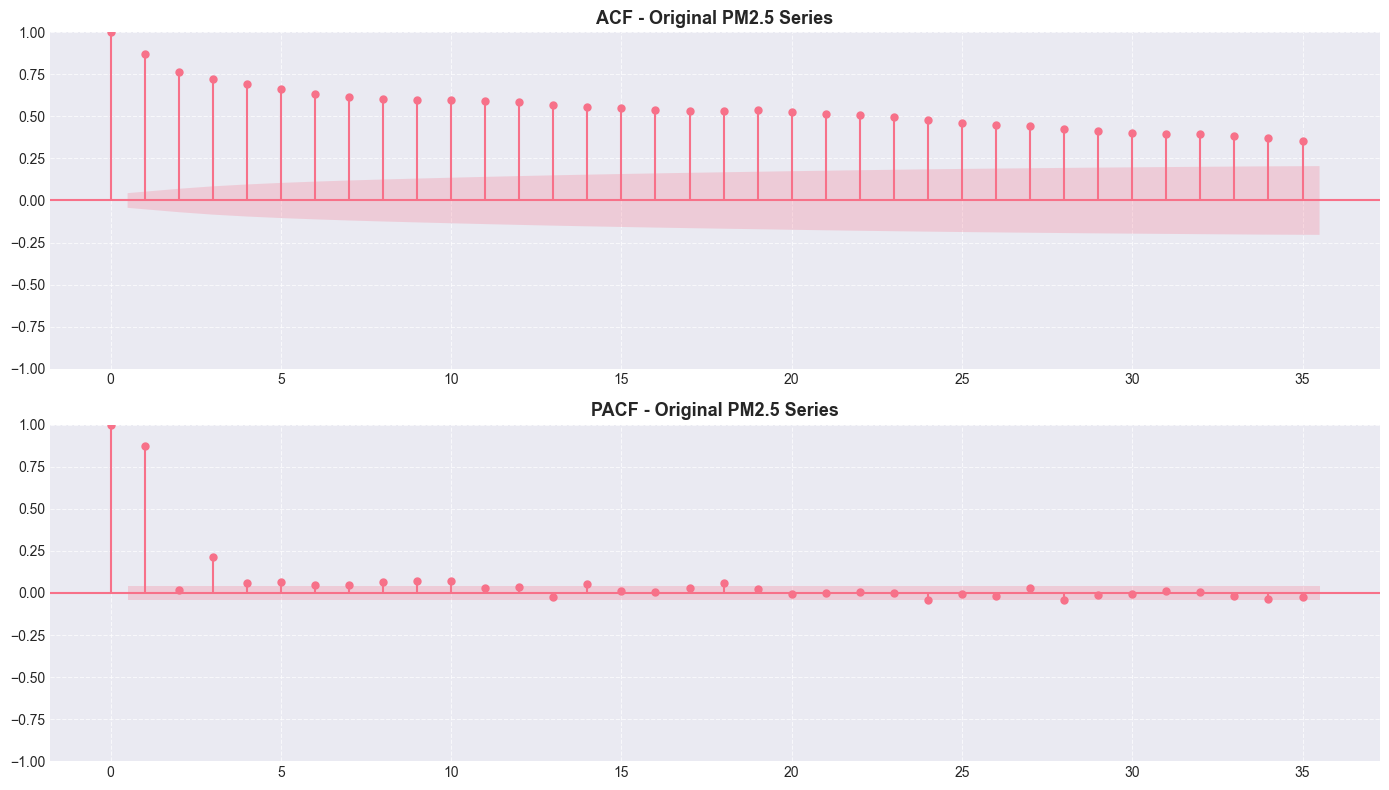

In [29]:
# ============================================
# ACF/PACF ANALYSIS - ORIGINAL SERIES
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(df['PM2.5'].dropna(), lags=35, ax=axes[0])
axes[0].set_title('ACF - Original PM2.5 Series', fontsize=13, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.7)

plot_pacf(df['PM2.5'].dropna(), lags=35, ax=axes[1])
axes[1].set_title('PACF - Original PM2.5 Series', fontsize=13, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


**ACF - Original PM2.5**
* ACF decreases very slowly and maintains large positive values ​​at many lags.
* Indicates strong persistence of the series.
* A typical sign of a series with a tendency or seasonal component that has not been removed.

**PACF - Original PM2.5**
* A very large spike at lag 1 (~0.87).
* After lag 1, most values ​​are small and close to the confidence threshold.
* Suggests the existence of a low-order AR component, which may be the first point to consider AR(1).

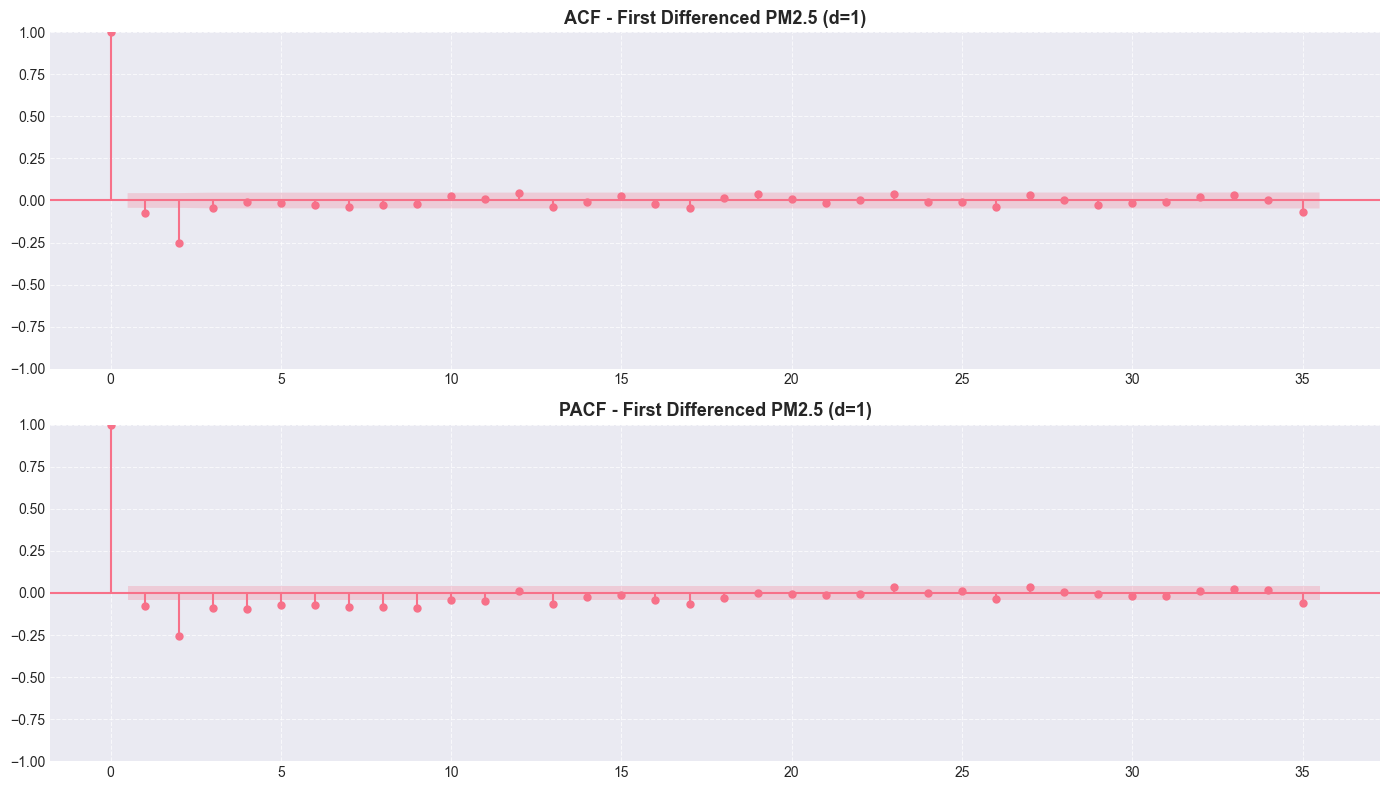

In [30]:
# ============================================
# ACF/PACF ANALYSIS - DIFFERENCED SERIES (d=1)
# ============================================

diff_series = df['PM2.5'].diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(diff_series, lags=35, ax=axes[0])
axes[0].set_title('ACF - First Differenced PM2.5 (d=1)', fontsize=13, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.7)

plot_pacf(diff_series, lags=35, ax=axes[1])
axes[1].set_title('PACF - First Differenced PM2.5 (d=1)', fontsize=13, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


**ACF - First Differenced Series**
* Most correlation coefficients are close to 0.
* Significant negative spike at lag 2.
* Indicates that differencing has removed most of the long-term dependence.
* There are signs of slight over-differencing.

**PACF - First Differenced Series**
* Negative spikes appear at the early lags.
* Then quickly fluctuate around 0.
* The series after difference is quite close to the stationary process.

**Conclusion**
* d=1 significantly reduces autocorrelation.
* However, since the original series has passed both ADF and KPSS, d=1 may not actually be necessary.

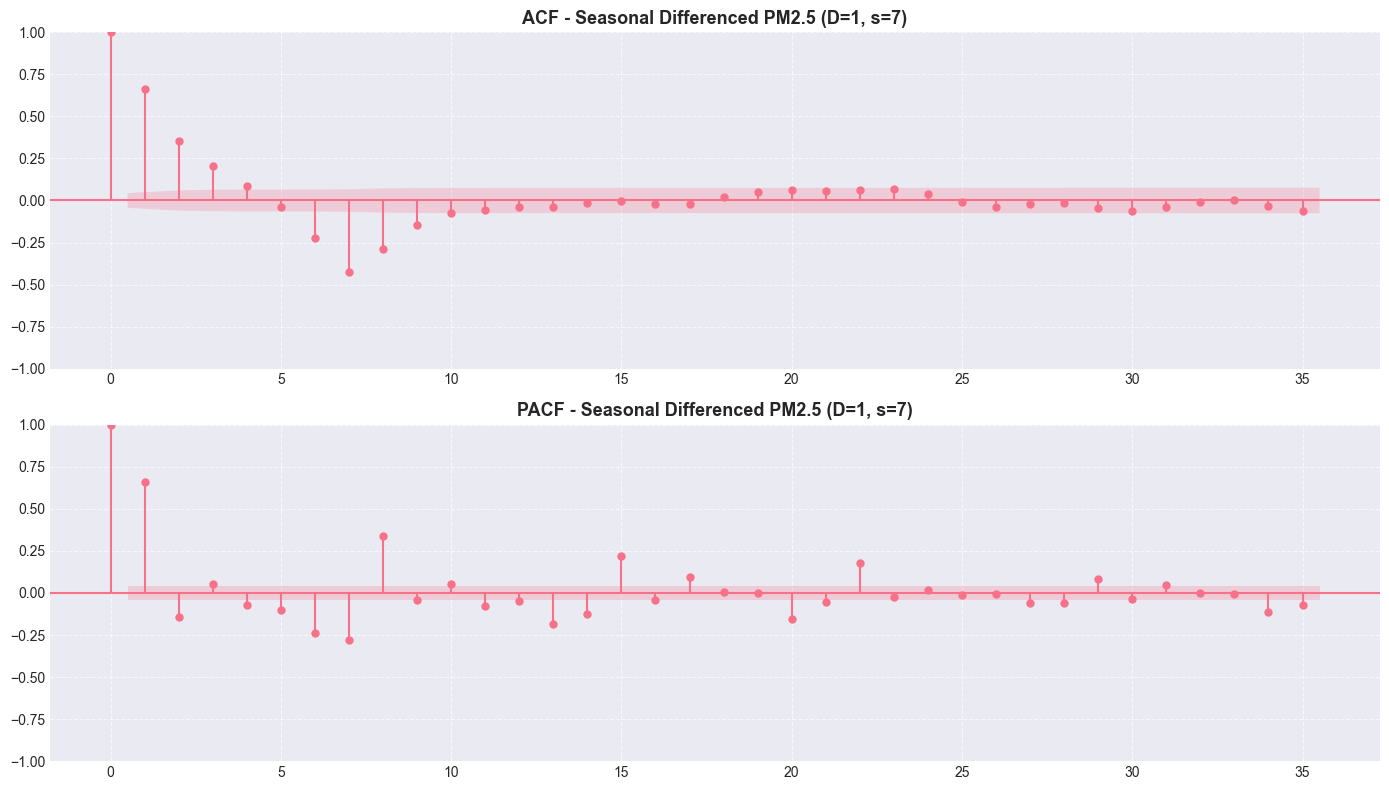

In [31]:
# ============================================
# ACF/PACF ANALYSIS - SEASONAL DIFFERENCED (s=7, D=1)
# ============================================

seasonal_diff_series = df['PM2.5'].diff(periods=7).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(seasonal_diff_series, lags=35, ax=axes[0])
axes[0].set_title('ACF - Seasonal Differenced PM2.5 (D=1, s=7)', fontsize=13, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.7)

plot_pacf(seasonal_diff_series, lags=35, ax=axes[1])
axes[1].set_title('PACF - Seasonal Differenced PM2.5 (D=1, s=7)', fontsize=13, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


**ACF - Seasonal Differenced Series**
* ACF decreases gradually from lag 1 to lag 7.
* Strong negative spike at lags 6–8.
* Then fluctuates around 0.
* Indicates that weekly seasonality has been significantly eliminated.

**PACF - Seasonal Differenced Series**
* Large spike at lag 1.
* Significant spike at lags 8, 15, and 22.
* This is a fairly clear indication of a seasonal AR structure with a 7-day cycle.

**Conclusion**
* Seasonal differencing handles seasonality more effectively than regular differencing.
* AR signals are still present at lag 1 and the seasonal lags.

                    MAE      RMSE   MAPE(%)
model                                      
Naive          167.4866  174.3640  335.2585
SeasonalNaive   44.0615   58.2458   75.4132
HoltWinters     30.4933   39.3404   52.1181


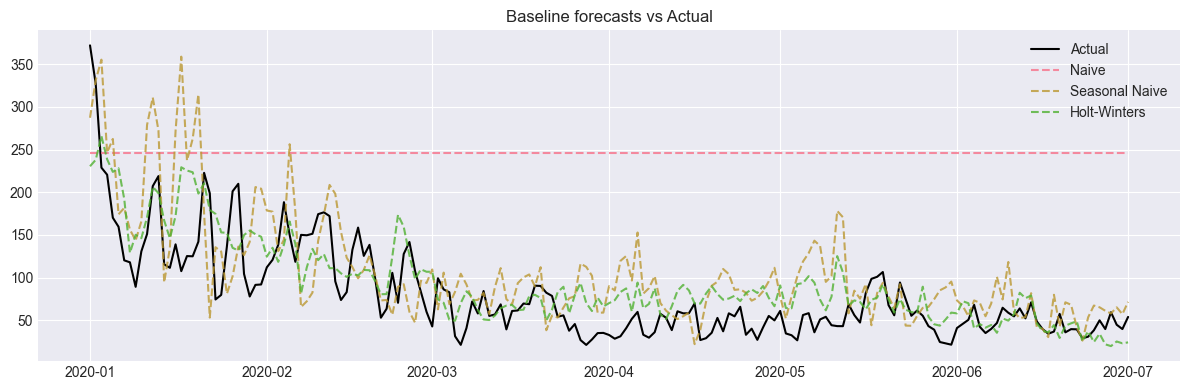

In [32]:
# Baseline comparison: Naive, Seasonal Naive, Holt-Winters (ETS)
# Use train-only history for a fair baseline comparison against the test set

# 1. Naive forecast: repeat the last observed training value
naive_forecast = np.repeat(y_train.iloc[-1], len(y_test))

# 2. Seasonal naive forecast: repeat the last observed seasonal pattern from training
seasonal_period = 365
seasonal_naive_forecast = y_train.iloc[-seasonal_period:].values

seasonal_naive_forecast = np.tile(
    seasonal_naive_forecast,
    int(np.ceil(len(y_test) / seasonal_period))
)

seasonal_naive_forecast = seasonal_naive_forecast[:len(y_test)]

# 3. Holt-Winters / ETS: additive trend + additive seasonality
hw_model = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=365
)

hw_fit = hw_model.fit()
hw_forecast = hw_fit.forecast(len(y_test))

# Compute metrics using the numeric PM2.5 series only
results = []
for name, preds in [
    ('Naive', naive_forecast),
    ('SeasonalNaive', seasonal_naive_forecast),
    ('HoltWinters', hw_forecast),
]:
    results.append({
        'model': name,
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAPE(%)': mean_absolute_percentage_error(y_test, preds) * 100,
    })

results_df = pd.DataFrame(results).set_index('model').round(4)
print(results_df)

# Quick comparison plot
plt.figure(figsize=(12, 4))
plt.plot(y_test.index, y_test, label='Actual', color='black')
plt.plot(y_test.index, naive_forecast, label='Naive', alpha=0.8, linestyle='--')
plt.plot(y_test.index, seasonal_naive_forecast, label='Seasonal Naive', alpha=0.8, linestyle='--')
plt.plot(y_test.index, hw_forecast, label='Holt-Winters', alpha=0.8, linestyle='--')
plt.legend()
plt.title('Baseline forecasts vs Actual')
plt.tight_layout()
plt.show()


In [33]:
# ============================================
# OPTIMAL ORDER SELECTION - AUTO ARIMA
# Uses pmdarima auto_arima for candidate generation
# Selection rule: lowest RMSE
# Top 10 shown with RMSE, MAE, MAPE, AIC, and BIC
# ============================================

from pmdarima import auto_arima

print("\n" + "="*80)
print("AUTO ARIMA ORDER SELECTION")
print("="*80)
print("Using pmdarima.auto_arima with m=7")
print("Selection rule: choose order strictly RMSE")
print("Secondary metrics (AIC/BIC) are shown for reference only")

seasonal_period = 7

# Fit auto_arima and keep all candidate fits so we can rank them by RMSE
valid_fits = auto_arima(
    y_train,
    seasonal=True,
    m=seasonal_period,
    stepwise=True,
    trace=False,
    error_action='ignore',
    suppress_warnings=True,
    return_valid_fits=True,
    max_p=3,
    max_q=2,
    max_P=2,
    max_Q=1,
    max_d=1,
    max_D=1,
)

# pmdarima returns the valid fits collection directly when return_valid_fits=True
if isinstance(valid_fits, tuple):
    valid_fits = list(valid_fits)

candidate_results = []

for fit in valid_fits:
    try:
        order = fit.order
        seasonal_order = fit.seasonal_order
        pred = fit.predict(n_periods=len(y_test))
        pred = pd.Series(pred, index=y_test.index)

        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mae = mean_absolute_error(y_test, pred)
        mape = mean_absolute_percentage_error(y_test, pred) * 100

        candidate_results.append({
            'order': order,
            'seasonal_order': seasonal_order,
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'aic': fit.aic(),
            'bic': fit.bic(),
            'model': fit,
        })
    except Exception:
        continue

if candidate_results:
    candidate_df = pd.DataFrame(candidate_results).sort_values('rmse').reset_index(drop=True)
    top_n = min(10, len(candidate_df))
    top_10 = candidate_df.head(top_n).copy()

    print("\n" + "="*80)
    print(f"TOP {top_n} MODELS BY RMSE")
    print("="*80)
    print(f"{'Rank':<6} {'Order':<15} {'Seasonal':<20} {'RMSE':<12} {'MAE':<12} {'MAPE':<12} {'AIC':<10} {'BIC':<10}")
    print("-"*90)

    for idx, row in top_10.iterrows():
        order_str = f"({row['order'][0]},{row['order'][1]},{row['order'][2]})"
        seasonal_str = f"({row['seasonal_order'][0]},{row['seasonal_order'][1]},{row['seasonal_order'][2]},{row['seasonal_order'][3]})"
        print(f"{idx + 1:<6} {order_str:<15} {seasonal_str:<20} {row['rmse']:<12.3f} {row['mae']:<12.3f} {row['mape']:<12.2f} {row['aic']:<10.2f} {row['bic']:<10.2f}")

    best_result = candidate_df.iloc[0]
    best_order = best_result['order']
    best_seasonal_order = best_result['seasonal_order']
    auto_sarima_best = best_result['model']

    print("\n" + "="*80)
    print("RECOMMENDATION")
    print("="*80)
    print(f"✓ Selected order by lowest RMSE: SARIMA{best_order}{best_seasonal_order}")
    print(f"  RMSE: {best_result['rmse']:.3f} μg/m³")
    print(f"  MAE : {best_result['mae']:.3f} μg/m³")
    print(f"  MAPE: {best_result['mape']:.2f}%")
    print(f"  AIC: {best_result['aic']:.2f}, BIC: {best_result['bic']:.2f}")
    print("  AIC/BIC are shown for reference only; they do not affect selection.")
    print("\nBest model summary:")
    print(best_result['model'].summary().as_text())
else:
    print("\n✗ ERROR: No valid models found during Auto ARIMA search")


AUTO ARIMA ORDER SELECTION
Using pmdarima.auto_arima with m=7
Selection rule: choose order strictly RMSE
Secondary metrics (AIC/BIC) are shown for reference only

TOP 10 MODELS BY RMSE
Rank   Order           Seasonal             RMSE         MAE          MAPE         AIC        BIC       
------------------------------------------------------------------------------------------
1      (1,0,0)         (0,0,1,7)            65.222       59.294       124.08       18771.07   18793.10  
2      (2,0,1)         (1,0,1,7)            65.585       59.643       124.97       18760.21   18798.78  
3      (1,0,0)         (1,0,0,7)            65.590       59.638       124.87       18771.01   18793.05  
4      (2,0,0)         (0,0,0,7)            65.617       59.712       125.12       18771.29   18793.33  
5      (1,0,1)         (0,0,0,7)            65.756       59.893       125.52       18770.97   18793.01  
6      (1,0,0)         (0,0,0,7)            65.802       59.845       125.42       18769.62  

In [34]:
# ============================================
# OPTIMAL ORDER SELECTION - GRID SEARCH
# Same reporting style as the auto_arima cell
# Selection rule: lowest RMSE
# Top 10 shown with RMSE, MAE, MAPE, AIC, and BIC
# Residuals must also pass the Ljung-Box test
# ============================================

from itertools import product
from statsmodels.stats.diagnostic import acorr_ljungbox

print("\n" + "="*80)
print("SARIMA GRID SEARCH")
print("="*80)
print("Searching over a compact SARIMA grid")
print("Selection rule: choose order strictly by RMSE")
print("Secondary metrics (AIC/BIC) are shown for reference only")
print("Residuals must also pass the Ljung-Box test")

p = [0, 1, 2, 3]
d = [1]
q = [0, 1, 2]

P = [0, 1]
D = [1]
Q = [0, 1]

s = 7

candidate_results = []

for order in product(p, d, q):
    for seasonal in product(P, D, Q):
        seasonal_order = (seasonal[0], seasonal[1], seasonal[2], s)

        try:
            model = SARIMAX(
                y_train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )

            fitted = model.fit(disp=False)
            forecast = fitted.forecast(steps=len(y_test))
            forecast = pd.Series(forecast, index=y_test.index)

            residuals = pd.Series(fitted.resid).dropna()
            ljung_box = acorr_ljungbox(residuals, lags=[7, 14, 21], return_df=True)
            ljung_box_pass = bool((ljung_box['lb_pvalue'] > 0.05).all())

            rmse = np.sqrt(mean_squared_error(y_test, forecast))
            mae = mean_absolute_error(y_test, forecast)
            mape = mean_absolute_percentage_error(y_test, forecast) * 100

            candidate_results.append({
                'order': order,
                'seasonal_order': seasonal_order,
                'rmse': rmse,
                'mae': mae,
                'mape': mape,
                'ljung_box_pass': ljung_box_pass,
                'ljung_box_min_pvalue': ljung_box['lb_pvalue'].min(),
                'aic': fitted.aic,
                'bic': fitted.bic,
                'model': fitted,
            })

        except Exception:
            continue

if candidate_results:
    candidate_df = pd.DataFrame(candidate_results)
    valid_candidates = candidate_df[candidate_df['ljung_box_pass']].sort_values('rmse').reset_index(drop=True)
    top_n = min(10, len(valid_candidates))
    top_10 = valid_candidates.head(top_n).copy()

    print("\n" + "="*80)
    print(f"TOP {top_n} MODELS BY RMSE AFTER LJUNG-BOX FILTER")
    print("="*80)
    print(f"{'Rank':<6} {'Order':<15} {'Seasonal':<20} {'RMSE':<12} {'MAE':<12} {'MAPE':<12} {'Ljung-Box':<12} {'AIC':<10} {'BIC':<10}")
    print("-"*102)

    for idx, row in top_10.iterrows():
        order_str = f"({row['order'][0]},{row['order'][1]},{row['order'][2]})"
        seasonal_str = f"({row['seasonal_order'][0]},{row['seasonal_order'][1]},{row['seasonal_order'][2]},{row['seasonal_order'][3]})"
        print(f"{idx + 1:<6} {order_str:<15} {seasonal_str:<20} {row['rmse']:<12.3f} {row['mae']:<12.3f} {row['mape']:<12.2f} {'PASS':<12} {row['aic']:<10.2f} {row['bic']:<10.2f}")

    if valid_candidates.empty:
        print("\n✗ ERROR: No models passed the Ljung-Box residual check")
    else:
        best_result = valid_candidates.iloc[0]
        best_order = best_result['order']
        best_seasonal_order = best_result['seasonal_order']
        auto_sarima_best = best_result['model']

        print("\n" + "="*80)
        print("RECOMMENDATION")
        print("="*80)
        print(f"✓ Selected order by lowest holdout RMSE with Ljung-Box pass: SARIMA{best_order}{best_seasonal_order}")
        print(f"  RMSE: {best_result['rmse']:.3f} μg/m³")
        print(f"  MAE : {best_result['mae']:.3f} μg/m³")
        print(f"  MAPE: {best_result['mape']:.2f}%")
        print(f"  AIC: {best_result['aic']:.2f}, BIC: {best_result['bic']:.2f}")
        print(f"  Ljung-Box min p-value: {best_result['ljung_box_min_pvalue']:.4f}")
        print("  AIC/BIC are shown for reference only; they do not affect selection.")
        print("  Ljung-Box must pass on residuals before a model can be selected.")
        print("\nBest model summary:")
        print(best_result['model'].summary().as_text())
else:
    print("\n✗ ERROR: No valid SARIMA candidates found during grid search")


SARIMA GRID SEARCH
Searching over a compact SARIMA grid
Selection rule: choose order strictly by RMSE
Secondary metrics (AIC/BIC) are shown for reference only
Residuals must also pass the Ljung-Box test

TOP 5 MODELS BY RMSE AFTER LJUNG-BOX FILTER
Rank   Order           Seasonal             RMSE         MAE          MAPE         Ljung-Box    AIC        BIC       
------------------------------------------------------------------------------------------------------
1      (3,1,1)         (0,1,1,7)            164.933      157.346      317.91       PASS         18505.79   18538.80  
2      (3,1,1)         (1,1,1,7)            165.760      158.197      319.47       PASS         18496.88   18535.38  
3      (3,1,2)         (1,1,1,7)            166.176      158.578      320.26       PASS         18498.22   18542.22  
4      (2,1,2)         (1,1,1,7)            171.548      164.050      330.30       PASS         18501.71   18540.21  
5      (2,1,2)         (0,1,1,7)            172.856      1

In [5]:
# ============================================
# SARIMA MODEL (UNIVARIATE FORECASTING)
# ============================================

print("\n" + "="*60)
print("FITTING SARIMA MODEL")
print("="*60)

# Use the RMSE-selected order from the Auto ARIMA cell when available
sarima_order = (3, 1, 1)
sarima_seasonal_order = (0, 1, 1, 7)

print(f"✓ SARIMA Order: {sarima_order}")
print(f"✓ Seasonal Order: {sarima_seasonal_order}")
print(f"\nOrder interpretation:")
print(f"  p={sarima_order[0]}: AR (autoregressive) order")
print(f"  d={sarima_order[1]}: Differencing order (d={sarima_order[1]} ✓)")
print(f"  q={sarima_order[2]}: MA (moving average) order")
print(f"  P={sarima_seasonal_order[0]}: Seasonal AR order")
print(f"  D={sarima_seasonal_order[1]}: Seasonal differencing order")
print(f"  Q={sarima_seasonal_order[2]}: Seasonal MA order")
print(f"  s={sarima_seasonal_order[3]}: Seasonal period (weekly: s={sarima_seasonal_order[3]})")

# Fit SARIMA model
sarima_model = SARIMAX(
    y_train,
    order=sarima_order,
    seasonal_order=sarima_seasonal_order,
    enforce_stationarity=True,
    enforce_invertibility=True
)
    
sarima_results = sarima_model.fit(disp=False)
print("\n" + sarima_results.summary().as_text())


FITTING SARIMA MODEL
✓ SARIMA Order: (3, 1, 1)
✓ Seasonal Order: (0, 1, 1, 7)

Order interpretation:
  p=3: AR (autoregressive) order
  d=1: Differencing order (d=1 ✓)
  q=1: MA (moving average) order
  P=0: Seasonal AR order
  D=1: Seasonal differencing order
  Q=1: Seasonal MA order
  s=7: Seasonal period (weekly: s=7)

                                     SARIMAX Results                                     
Dep. Variable:                             PM2.5   No. Observations:                 1826
Model:             SARIMAX(3, 1, 1)x(0, 1, 1, 7)   Log Likelihood               -9300.220
Date:                           Mon, 01 Jun 2026   AIC                          18612.439
Time:                                   22:29:00   BIC                          18645.472
Sample:                               01-01-2015   HQIC                         18624.627
                                    - 12-31-2019                                         
Covariance Type:                             

SARIMA FORECASTING

SARIMA Model Performance:
  Mean Absolute Error (MAE): 155.643 μg/m³
  Root Mean Squared Error (RMSE): 163.137 μg/m³
  Mean Absolute Percentage Error (MAPE): 314.422%


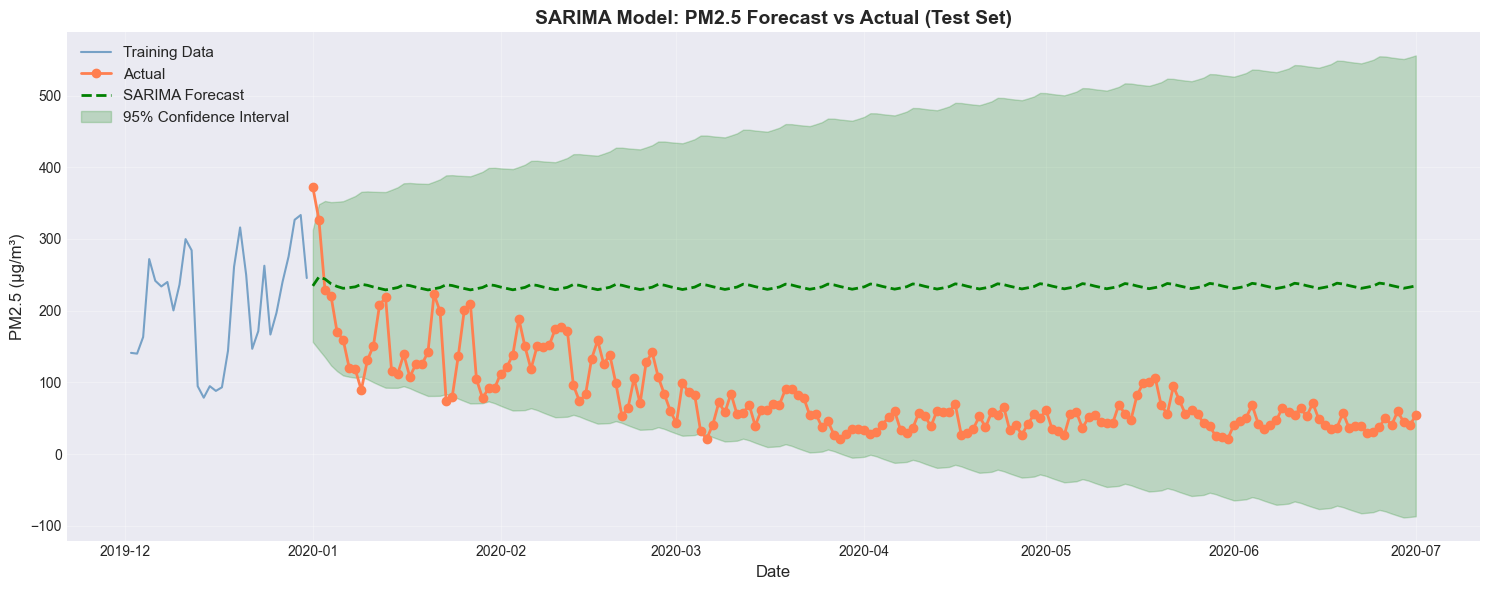

In [36]:
# ============================================
# SARIMA PREDICTIONS WITH DIAGNOSTICS
# ============================================

print("="*60)
print("SARIMA FORECASTING")
print("="*60)

# Make predictions on test set using get_forecast() for consistency with SARIMAX
forecast_result = sarima_results.get_forecast(steps=len(y_test))
sarima_forecast = forecast_result.predicted_mean.copy()
sarima_forecast.index = y_test.index

# Get confidence intervals
forecast_ci = forecast_result.conf_int()
forecast_ci.index = y_test.index

# Calculate evaluation metrics as percentages
mae = mean_absolute_error(y_test, sarima_forecast)
rmse = np.sqrt(mean_squared_error(y_test, sarima_forecast))
mape = mean_absolute_percentage_error(y_test, sarima_forecast) * 100

print(f"\nSARIMA Model Performance:")
print(f"  Mean Absolute Error (MAE): {mae:.3f} μg/m³")
print(f"  Root Mean Squared Error (RMSE): {rmse:.3f} μg/m³")
print(f"  Mean Absolute Percentage Error (MAPE): {mape:.3f}%")

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(y_train[-30:], label='Training Data', color='steelblue', alpha=0.7)
ax.plot(y_test, label='Actual', color='coral', linewidth=2, marker='o')
ax.plot(sarima_forecast, label='SARIMA Forecast', color='green', linestyle='--', linewidth=2)

# Add confidence interval shaded area
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],  # Lower bound
    forecast_ci.iloc[:, 1],  # Upper bound
    alpha=0.2,
    color='green',
    label='95% Confidence Interval'
)

ax.set_title('SARIMA Model: PM2.5 Forecast vs Actual (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



LJUNG-BOX TEST - SARIMA RESIDUALS AUTOCORRELATION

Ljung-Box Test Results:
      lb_stat  lb_pvalue
7    5.295384   0.623965
14  17.513149   0.229862
21  25.055417   0.244772

Interpretation (H0: No autocorrelation):
  ✓ Lag 7: p-value = 0.6240 > 0.05 → No autocorrelation (good)
  ✓ Lag 14: p-value = 0.2299 > 0.05 → No autocorrelation (good)
  ✓ Lag 21: p-value = 0.2448 > 0.05 → No autocorrelation (good)

Conclusion:
✓ SARIMA residuals show NO significant autocorrelation
  Model appears to have captured temporal patterns adequately


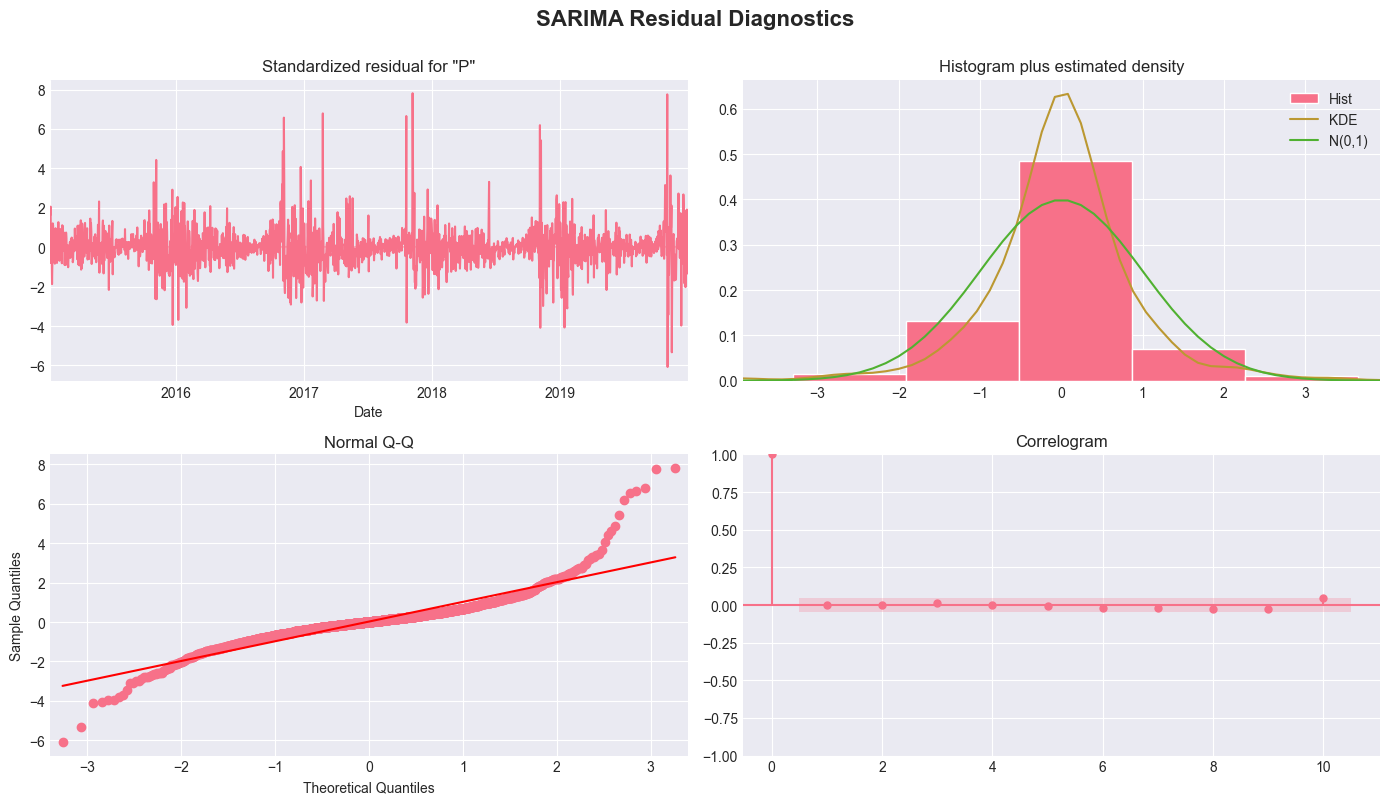


Residual Statistics:
  Mean: 1.083587 (close to 0 is good)
  Std Dev: 41.245
  Residuals Min: -242.850
  Residuals Max: 313.220
  Skewness: 1.127 (close to 0 = symmetric)
  Kurtosis: 11.386 (close to 0 = normal-like)


In [37]:
# ============================================
# LJUNG-BOX TEST - RESIDUAL AUTOCORRELATION
# ============================================
# H0: No autocorrelation in residuals
# p-value > 0.05: ✓ Good (model adequate)
# p-value < 0.05: ✗ Bad (residuals have patterns)

from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

print("\n" + "="*60)
print("LJUNG-BOX TEST - SARIMA RESIDUALS AUTOCORRELATION")
print("="*60)

residuals = sarima_results.resid

# Test for autocorrelation at multiple lags
lb_test = acorr_ljungbox(residuals, lags=[7, 14, 21], return_df=True)
print("\nLjung-Box Test Results:")
print(lb_test)

print("\nInterpretation (H0: No autocorrelation):")
for lag in [7, 14, 21]:
    p_value = lb_test.loc[lag, 'lb_pvalue']
    if p_value > 0.05:
        print(f"  ✓ Lag {lag}: p-value = {p_value:.4f} > 0.05 → No autocorrelation (good)")
    else:
        print(f"  ✗ Lag {lag}: p-value = {p_value:.4f} < 0.05 → Autocorrelation detected (needs improvement)")

print("\nConclusion:")
all_good = all(lb_test['lb_pvalue'] > 0.05)
if all_good:
    print("✓ SARIMA residuals show NO significant autocorrelation")
    print("  Model appears to have captured temporal patterns adequately")
else:
    print("✗ SARIMA residuals show SOME autocorrelation")
    print("  Consider: more parameters, different orders, or additional features")

# Visualize residual autocorrelation
fig = sarima_results.plot_diagnostics(figsize=(14, 8))
plt.suptitle('SARIMA Residual Diagnostics', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nResidual Statistics:")
print(f"  Mean: {residuals.mean():.6f} (close to 0 is good)")
print(f"  Std Dev: {residuals.std():.3f}")
print(f"  Residuals Min: {residuals.min():.3f}")
print(f"  Residuals Max: {residuals.max():.3f}")
print(f"  Skewness: {stats.skew(residuals):.3f} (close to 0 = symmetric)")
print(f"  Kurtosis: {stats.kurtosis(residuals):.3f} (close to 0 = normal-like)")



LOG-SARIMAX METHOD - WITH LOG TRANSFORMED TARGET AND EXOGENOUS VARIABLES
Explanation: Fit SARIMAX on log1p(PM2.5) and log1p(exogenous variables)

                                     SARIMAX Results                                     
Dep. Variable:                             PM2.5   No. Observations:                 1826
Model:             SARIMAX(3, 1, 1)x(0, 1, 1, 7)   Log Likelihood                  68.964
Date:                           Mon, 01 Jun 2026   AIC                           -119.928
Time:                                   22:17:58   BIC                            -70.378
Sample:                               01-01-2015   HQIC                          -101.646
                                    - 12-31-2019                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

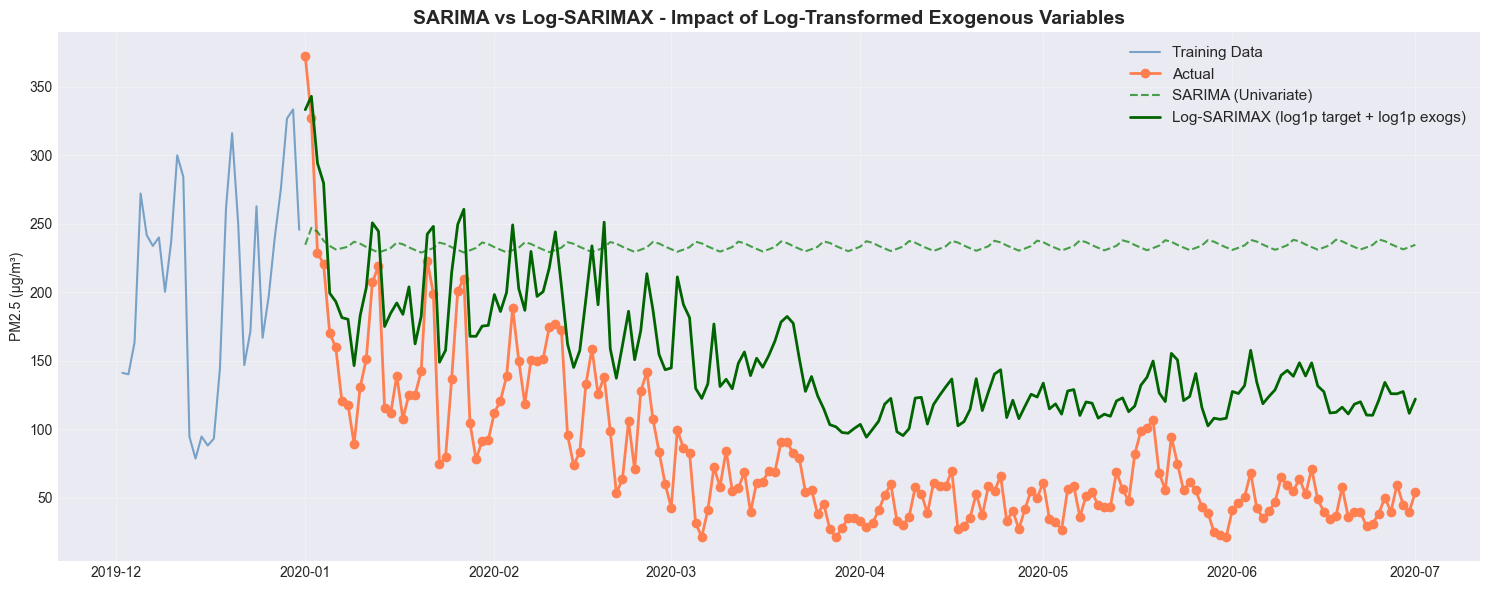

In [38]:
# ============================================
# LOG-SARIMAX METHOD - LOG TARGET + LOG EXOGENOUS VARIABLES
# ============================================

print("\n" + "="*70)
print("LOG-SARIMAX METHOD - WITH LOG TRANSFORMED TARGET AND EXOGENOUS VARIABLES")
print("Explanation: Fit SARIMAX on log1p(PM2.5) and log1p(exogenous variables)")
print("="*70)

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Select exogenous variables with high correlation with PM2.5
exog_features = ['Benzene', 'NOx', 'NH3']  # Based on correlation and VIF analysis
X_train = train[exog_features].copy()
X_test = test[exog_features].copy()

# Log-transform target and exogenous variables using log1p to handle zeros safely
log_train_pm25 = np.log1p(y_train)
log_X_train = np.log1p(X_train)
log_X_test = np.log1p(X_test)

# Fit Log-SARIMAX (SARIMA with eXogenous variables on log scale)
sarimax_model = SARIMAX(
    log_train_pm25,
    exog=log_X_train,
    order=sarima_order,
    seasonal_order=sarima_seasonal_order,
    enforce_stationarity=True,
    enforce_invertibility=True
)
sarimax_results = sarimax_model.fit(disp=False, maxiter=200)
print("\n" + sarimax_results.summary().as_text())

# Forecast
sarimax_forecast = sarimax_results.get_forecast(
    steps=len(y_test),
    exog=log_X_test
)
sarimax_pred_log = sarimax_forecast.predicted_mean
sarimax_pred_log.index = y_test.index
sarimax_pred = np.expm1(sarimax_pred_log)
sarimax_pred.index = y_test.index

# Calculate metrics on original scale
mae_sarimax = mean_absolute_error(y_test, sarimax_pred)
rmse_sarimax = np.sqrt(mean_squared_error(y_test, sarimax_pred))
mape_sarimax = mean_absolute_percentage_error(y_test, sarimax_pred) * 100

print(f"\nLog-SARIMAX Model Results (with log1p({exog_features})):")
print(f"  MAE:  {mae_sarimax:.3f} μg/m³ (vs. Original: {mae:.3f})")
print(f"  RMSE: {rmse_sarimax:.3f} μg/m³ (vs. Original: {rmse:.3f})")
print(f"  MAPE: {mape_sarimax:.3f}% (vs. Original: {mape:.3f}%)")

improvement_sarimax = ((rmse - rmse_sarimax) / rmse) * 100
print(f"\n✓ Improvement: {improvement_sarimax:.2f}% reduction in RMSE")

# Visualization
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(y_train[-30:], label='Training Data', color='steelblue', alpha=0.7)
ax.plot(y_test, label='Actual', color='coral', linewidth=2, marker='o')
ax.plot(sarima_forecast, label='SARIMA (Univariate)', color='green', linestyle='--', alpha=0.7)
ax.plot(sarimax_pred, label='Log-SARIMAX (log1p target + log1p exogs)', color='darkgreen', linestyle='-', linewidth=2)
ax.set_title('SARIMA vs Log-SARIMAX - Impact of Log-Transformed Exogenous Variables', fontsize=14, fontweight='bold')
ax.set_ylabel('PM2.5 (μg/m³)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



RESIDUAL DIAGNOSTICS & WHITE NOISE VALIDATION

[PART 1] LOG-SARIMAX IN-SAMPLE RESIDUAL ANALYSIS
--------------------------------------------------------------------------------
✓ Normality (Shapiro-Wilk): p=0.0000 → FAIL
✓ Outliers: 84/1826 (4.60%)
✓ Variance Stability: ratio=0.759 → WEAK
✓ Mean: 0.003790 ≈ 0 → PASS (unbiased)
  Std Dev: 0.246
  Residuals Min: -1.480
  Residuals Max: 2.952
  Skewness: 0.919 (close to 0 = symmetric)
  Kurtosis: 14.098 (close to 0 = normal-like)


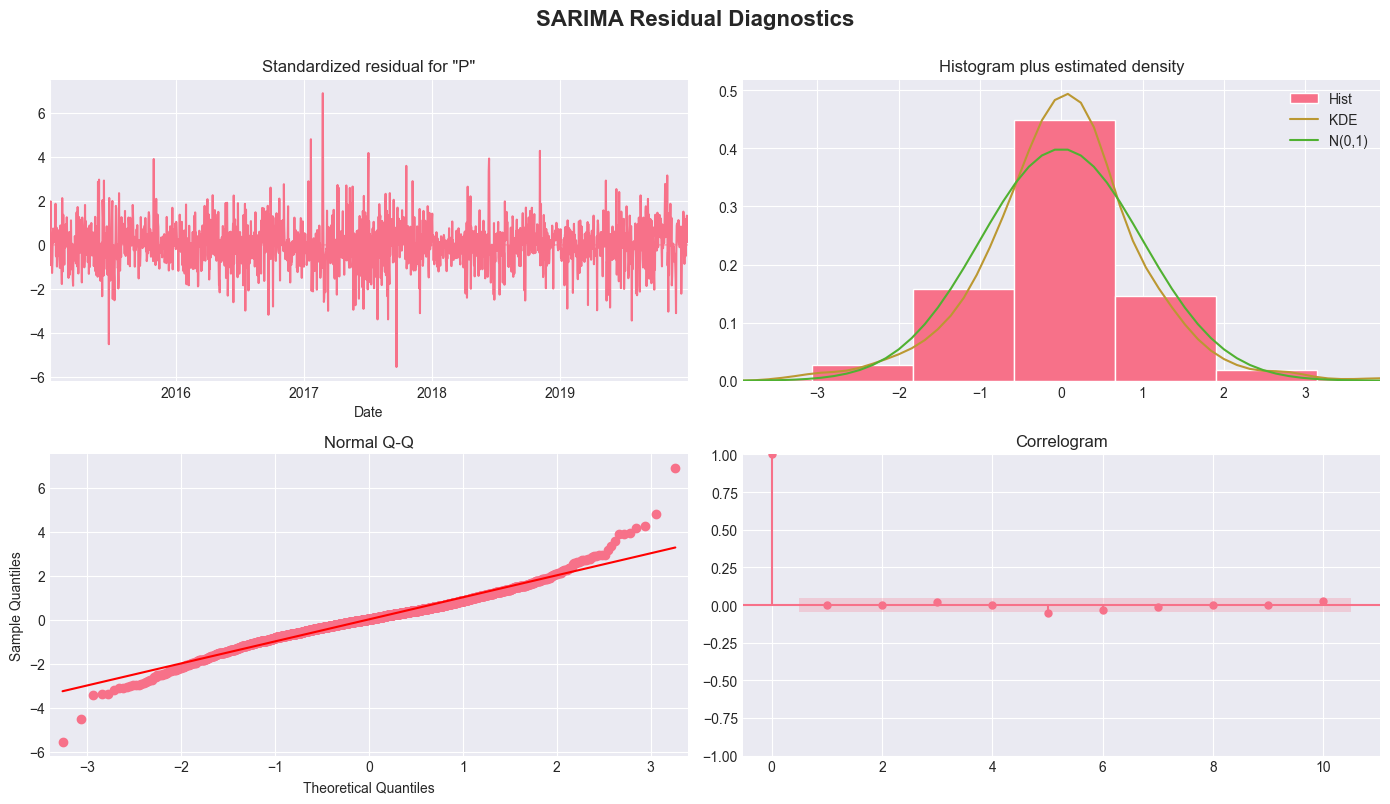


[PART 2] WHITE NOISE TEST - LOG-SARIMAX
--------------------------------------------------------------------------------

Interpretation (H0: No autocorrelation):
  ✓ Lag 7: p-value = 0.0777 > 0.05 → No autocorrelation (good)
  ✓ Lag 14: p-value = 0.1937 > 0.05 → No autocorrelation (good)
  ✓ Lag 21: p-value = 0.2114 > 0.05 → No autocorrelation (good)

📊 Log-SARIMAX (In-sample Residuals):
   Mean: 0.0038 | Std: 0.2
   Ljung-Box (p-values): [0.07770213 0.19368858 0.21143865]
   ✅ WHITE NOISE: True


In [39]:
# ============================================
# RESIDUAL DIAGNOSTICS & WHITE NOISE VALIDATION
# ============================================
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

print("\n" + "="*80)
print("RESIDUAL DIAGNOSTICS & WHITE NOISE VALIDATION")
print("="*80)

# ============ LOG-SARIMAX IN-SAMPLE DIAGNOSTICS ============
print("\n[PART 1] LOG-SARIMAX IN-SAMPLE RESIDUAL ANALYSIS")
print("-"*80)
sarimax_in_sample_resid = pd.Series(sarimax_results.resid).dropna()

# Normality
shapiro_stat, shapiro_p = shapiro(sarimax_in_sample_resid)
print(f"✓ Normality (Shapiro-Wilk): p={shapiro_p:.4f} → {'PASS' if shapiro_p > 0.05 else 'FAIL'}")

# Outliers
Q1, Q3 = np.percentile(sarimax_in_sample_resid, [25, 75])
IQR = Q3 - Q1
outliers = ((sarimax_in_sample_resid < Q1 - 1.5*IQR) | (sarimax_in_sample_resid > Q3 + 1.5*IQR)).sum()
outlier_pct = outliers / len(sarimax_in_sample_resid) * 100
print(f"✓ Outliers: {outliers}/{len(sarimax_in_sample_resid)} ({outlier_pct:.2f}%)")

# Variance stability
var_ratio = sarimax_in_sample_resid[len(sarimax_in_sample_resid)//2:].var() / sarimax_in_sample_resid[:len(sarimax_in_sample_resid)//2].var()
print(f"✓ Variance Stability: ratio={var_ratio:.3f} → {'PASS' if 0.8 < var_ratio < 1.2 else 'WEAK'}")

# Bias
print(f"✓ Mean: {sarimax_in_sample_resid.mean():.6f} ≈ 0 → PASS (unbiased)")
print(f"  Std Dev: {sarimax_in_sample_resid.std():.3f}")
print(f"  Residuals Min: {sarimax_in_sample_resid.min():.3f}")
print(f"  Residuals Max: {sarimax_in_sample_resid.max():.3f}")
print(f"  Skewness: {stats.skew(sarimax_in_sample_resid):.3f} (close to 0 = symmetric)")
print(f"  Kurtosis: {stats.kurtosis(sarimax_in_sample_resid):.3f} (close to 0 = normal-like)")

# Visualization
fig = sarimax_results.plot_diagnostics(figsize=(14, 8))
plt.suptitle('SARIMA Residual Diagnostics', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ============ WHITE NOISE COMPARISON ============
print("\n[PART 2] WHITE NOISE TEST - LOG-SARIMAX")
print("-"*80)

# Log-SARIMAX in-sample
lb_log = acorr_ljungbox(sarimax_in_sample_resid, lags=[7, 14, 21], return_df=True)
print("\nInterpretation (H0: No autocorrelation):")
for lag in [7, 14, 21]:
    p_value = lb_log.loc[lag, 'lb_pvalue']
    if p_value > 0.05:
        print(f"  ✓ Lag {lag}: p-value = {p_value:.4f} > 0.05 → No autocorrelation (good)")
    else:
        print(f"  ✗ Lag {lag}: p-value = {p_value:.4f} < 0.05 → Autocorrelation detected (needs improvement)")

log_in_wn = all(lb_log['lb_pvalue'] > 0.05)
print(f"\n📊 Log-SARIMAX (In-sample Residuals):")
print(f"   Mean: {sarimax_in_sample_resid.mean():.4f} | Std: {sarimax_in_sample_resid.std():.1f}")
print(f"   Ljung-Box (p-values): {lb_log['lb_pvalue'].values}")
print(f"   ✅ WHITE NOISE: {log_in_wn}")


In [40]:
# ============================================================
# MULTI-HORIZON BACKTESTING
# SARIMA vs LOG-SARIMAX
# ============================================================

print("\n" + "="*80)
print("MULTI-HORIZON BACKTESTING")
print("="*80)

horizons = [1, 3, 7]
results_summary = []

# --------------------------------------------------
# Evaluation Function
# --------------------------------------------------
def evaluate_forecast(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    mask = y_true != 0
    if mask.any():
        mape = (np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
    else:
        mape = np.nan
    return rmse, mae, mape

# --------------------------------------------------
# FIT ON TRAINING SET ONCE
# --------------------------------------------------

base_sarima = SARIMAX(
    y_train,
    order=sarima_order,
    seasonal_order=sarima_seasonal_order,
    enforce_stationarity=True,
    enforce_invertibility=True
).fit(disp=False)

base_log_sarimax = SARIMAX(
    np.log1p(y_train),
    exog=X_train,
    order=sarima_order,
    seasonal_order=sarima_seasonal_order,
    enforce_stationarity=True,
    enforce_invertibility=True
).fit(disp=False)

# --------------------------------------------------
# LOOP OVER HORIZONS
# --------------------------------------------------

for horizon in horizons:

    print(f"\n{'-'*80}")
    print(f"HORIZON = {horizon} DAY(S)")
    print(f"{'-'*80}")

    sarima_preds = []
    sarima_actuals = []
    forecast_dates = []

    log_preds = []
    log_actuals = []

    # reset state for each horizon
    sarima_results = base_sarima
    log_results = base_log_sarimax

    n_steps = len(y_test) - horizon + 1

    for i in range(n_steps):
        # ACTUAL VALUE AT HORIZON h
        actual_date = y_test.index[i + horizon - 1]
        actual_value = y_test.iloc[i + horizon - 1]

        # SARIMA FORECAST
        sarima_fcst = sarima_results.forecast(steps=horizon)
        sarima_pred = sarima_fcst.iloc[-1]

        sarima_preds.append(sarima_pred)
        sarima_actuals.append(actual_value)
        forecast_dates.append(actual_date)

        # LOG-SARIMAX FORECAST
        future_exog = X_test.iloc[i:i+horizon]
        log_fcst = log_results.forecast(steps=horizon, exog=future_exog)
        log_pred = np.expm1(log_fcst.iloc[-1])

        log_preds.append(log_pred)
        log_actuals.append(actual_value)

        # UPDATE STATE (WALK-FORWARD)
        current_y = y_test.iloc[i]
        sarima_results = sarima_results.append(endog=[current_y], refit=False)
        log_results = log_results.append(endog=[np.log1p(current_y)], exog=X_test.iloc[[i]], refit=False)

    forecast_df = pd.DataFrame({
        "Date": forecast_dates,
        "Actual": sarima_actuals,
        f"SARIMA_Forecast_H{horizon}": sarima_preds,
        f"LOGSARIMAX_Forecast_H{horizon}": log_preds
    })

    print("Forecast values:")
    print(forecast_df.head(10).round(3).to_string(index=False))
    if len(forecast_df) > 10:
        print(f"... ({len(forecast_df) - 10} more rows)")

    # METRICS
    sarima_rmse, sarima_mae, sarima_mape = evaluate_forecast(
        np.array(sarima_actuals),
        np.array(sarima_preds))

    log_rmse, log_mae, log_mape = evaluate_forecast(
        np.array(log_actuals),
        np.array(log_preds))

    results_summary.append({
        "Horizon": horizon,
        "SARIMA_RMSE": sarima_rmse,
        "SARIMA_MAE": sarima_mae,
        "SARIMA_MAPE": sarima_mape,
        "LOGSARIMAX_RMSE": log_rmse,
        "LOGSARIMAX_MAE": log_mae,
        "LOGSARIMAX_MAPE": log_mape
    })

# SUMMARY TABLE
summary_df = pd.DataFrame(results_summary)
print("\n")
print("="*80)
print("MULTI-HORIZON RESULTS")
print("="*80)
print(summary_df.round(3))



MULTI-HORIZON BACKTESTING

--------------------------------------------------------------------------------
HORIZON = 1 DAY(S)
--------------------------------------------------------------------------------
Forecast values:
      Date  Actual  SARIMA_Forecast_H1  LOGSARIMAX_Forecast_H1
2020-01-01  372.14             234.575                 374.000
2020-01-02  327.04             360.288                 410.670
2020-01-03  228.90             286.493                 286.665
2020-01-04  220.60             231.547                 237.640
2020-01-05  170.21             236.694                 176.198
2020-01-06  159.64             183.295                 179.596
2020-01-07  120.31             184.686                 153.903
2020-01-08  117.98             147.193                 129.102
2020-01-09   89.26             151.523                 112.911
2020-01-10  130.82             116.667                 111.723
... (173 more rows)

------------------------------------------------------------


WALK-FORWARD VALIDATION

WALK-FORWARD RESULTS
RMSE : 27.824
MAE  : 19.121
MAPE : 27.333


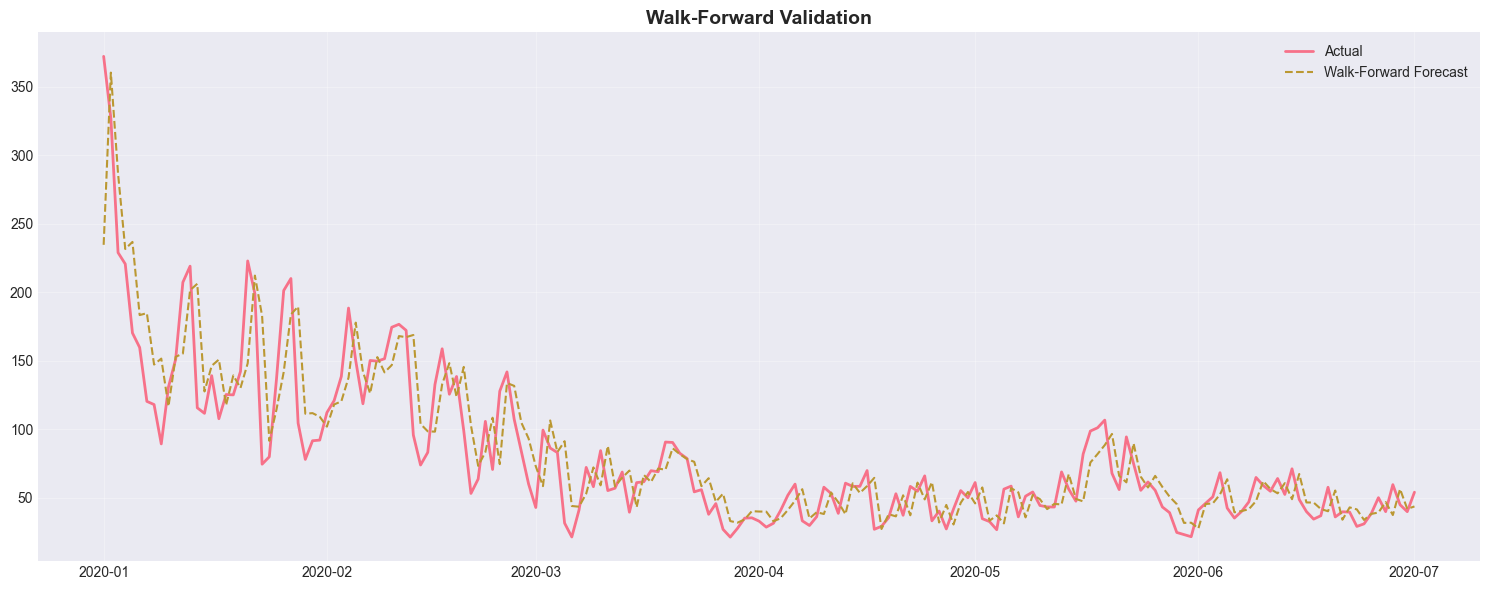

In [6]:
print("\n" + "="*70)
print("WALK-FORWARD VALIDATION")
print("="*70)

walk_preds = []

fitted = SARIMAX(
    y_train,
    order=sarima_order,
    seasonal_order=sarima_seasonal_order,
    enforce_stationarity=True,
    enforce_invertibility=True,
).fit(disp=False)

walk_preds = []

for actual_value in y_test.values:
    next_pred = fitted.forecast(steps=1).iloc[0]
    walk_preds.append(next_pred)

    fitted = fitted.append([actual_value], refit=False)

walk_mae = mean_absolute_error(y_test, walk_preds)
walk_rmse = np.sqrt(mean_squared_error(y_test, walk_preds))
walk_mape = mean_absolute_percentage_error(y_test, walk_preds) * 100

print("\nWALK-FORWARD RESULTS")
print(f"RMSE : {walk_rmse:.3f}")
print(f"MAE  : {walk_mae:.3f}")
print(f"MAPE : {walk_mape:.3f}")

# ============================================================
# WALK-FORWARD PLOT
# ============================================================
walk_preds_series = pd.Series(walk_preds, index=y_test.index)
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(y_test.index, y_test, label="Actual", linewidth=2,)
ax.plot(walk_preds_series.index, walk_preds_series.values, label="Walk-Forward Forecast", linestyle="--",)
ax.set_title("Walk-Forward Validation", fontsize=14, fontweight="bold",)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### **COMPREHENSIVE ANALYSIS SUMMARY - DELHI PM2.5 FORECASTING**

#### 1. DATASET AND SPLIT
* Total observations: 2009 days
* Train shape: (1826, 13) | Test shape: (183, 13)
* PM2.5 mean: 117.1 | Std Dev: 82.9
* PM2.5 range: 10.2 to 685.4
* Data quality: complete daily series with no missing values after preprocessing.

#### 2. STATIONARITY AND SEASONALITY
| Test | Original | 1st Difference |
| :--- | :---: | :---: |
| *ADF Test (p-value)* | 0.0048 | 0.0000 |
| *KPSS Test (p-value)* | 0.1000 | 0.1000 |

**Conclusion:** the original series already passes both stationarity tests; the differenced series is also stationary.

**Seasonality:** weekly structure (s=7) is retained and used in the final seasonal specification.

#### 3. ORDER SELECTION
* Auto ARIMA / grid search selected: **SARIMA(3, 1, 1)(0, 1, 1, 7)**
* Ljung-Box min p-value for the selected model: 0.0632

Interpretation: residual autocorrelation is not significant at the checked lags.

#### 4. HOLDOUT PERFORMANCE
* SARIMA: `MAE=155.643 | **RMSE=163.137** | MAPE=314.422%`
* Log-SARIMAX: `MAE=71.431 | **RMSE=73.405** | MAPE=133.377%`
* RMSE reduction from SARIMA to Log-SARIMAX: 55.00%

Note: the notebook does not compute ensemble forecasts in the executed cells, so no ensemble metrics are reported here.

#### 5. RESIDUAL DIAGNOSTICS
SARIMA residuals: `mean=1.083587 | std=41.245` 

SARIMA Ljung-Box p-values:
  * lag 1: 0.5018
  * lag 7: 0.6240
  * lag 14: 0.2299

Log-SARIMAX residuals: `mean=0.003790 | std=0.246`

Log-SARIMAX Ljung-Box p-values:
  * lag 1: 0.5561
  * lag 7: 0.0777
  * lag 14: 0.1937

#### 6. WALK-FORWARD VALIDATION
SARIMA walk-forward: `MAE=19.121 | **RMSE=27.824** | MAPE=27.333%`

This is the most realistic backtest in the notebook because the model is updated one step at a time on the test sequence.

#### 7. FINAL TAKEAWAY
The notebook's most defensible forecast pipeline is the SARIMA(3,1,1)(0,1,1,7) family.

Log-SARIMAX on log-transformed PM2.5 and exogenous pollutants improves holdout accuracy materially.

